# Ingestion Dataset

In [ ]:
!pip install kaggle --quiet

# Sube tu kaggle.json (lo descargas desde kaggle.com → Account → Create New API Token)
import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
# Mueve kaggle.json a ~/.kaggle/ y dale permisos:
!chmod 600 ~/.kaggle/kaggle.json

# Descargar y descomprimir
!kaggle datasets download -d joebeachcapital/dry-beans --unzip -p ./data pq

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/joebeachcapital/dry-beans
License(s): Attribution 4.0 International (CC BY 4.0)
100% 4.53M/4.53M [00:00<00:00, 187MB/s]



In [7]:
import os
for root, dirs, files in os.walk("./data"):
    for f in files:
        print(os.path.join(root, f))


./data/DryBeanDataset/Dry_Bean_Dataset.txt
./data/DryBeanDataset/Dry_Bean_Dataset.xlsx
./data/DryBeanDataset/Dry_Bean_Dataset.arff


# EDA

In [10]:
from pathlib import Path
import pandas as pd

# Sube hasta encontrar la carpeta data, sin importar desde dónde corras
ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

df = pd.read_excel(ROOT / "data" / "DryBeanDataset" / "Dry_Bean_Dataset.xlsx")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64
Filas duplicadas: 68
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


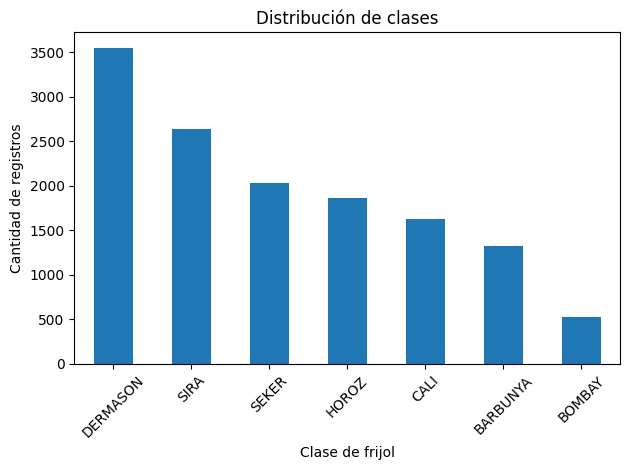

In [13]:
import matplotlib.pyplot as plt

missing_values = df.isna().sum()
duplicated_rows = df.duplicated().sum()
print(missing_values)
print("Filas duplicadas:", duplicated_rows)
df = df.drop_duplicates()

class_counts = df["Class"].value_counts()
print(class_counts)
class_counts.plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase de frijol")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

X = df.drop(columns="Class")
y = df["Class"]

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Proporciones:
Class
DERMASON    0.262
SIRA        0.195
SEKER       0.150
HOROZ       0.137
CALI        0.120
BARBUNYA    0.098
BOMBAY      0.039
Name: proportion, dtype: float64


/tmp/ipykernel_2014/1482839845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', order=class_counts.index, palette='viridis')


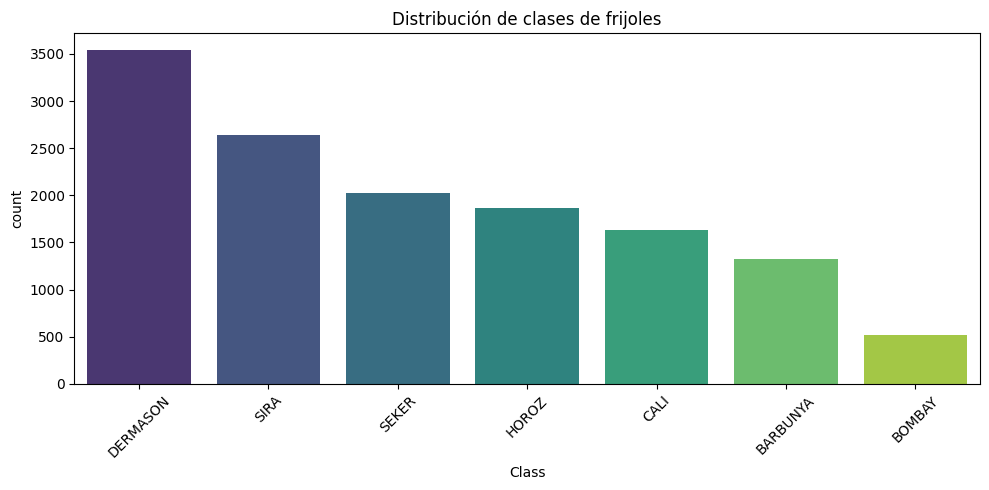

In [14]:
import seaborn as sns
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nProporciones:\n{df['Class'].value_counts(normalize=True).round(3)}")

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Class', order=class_counts.index, palette='viridis')
plt.title('Distribución de clases de frijoles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

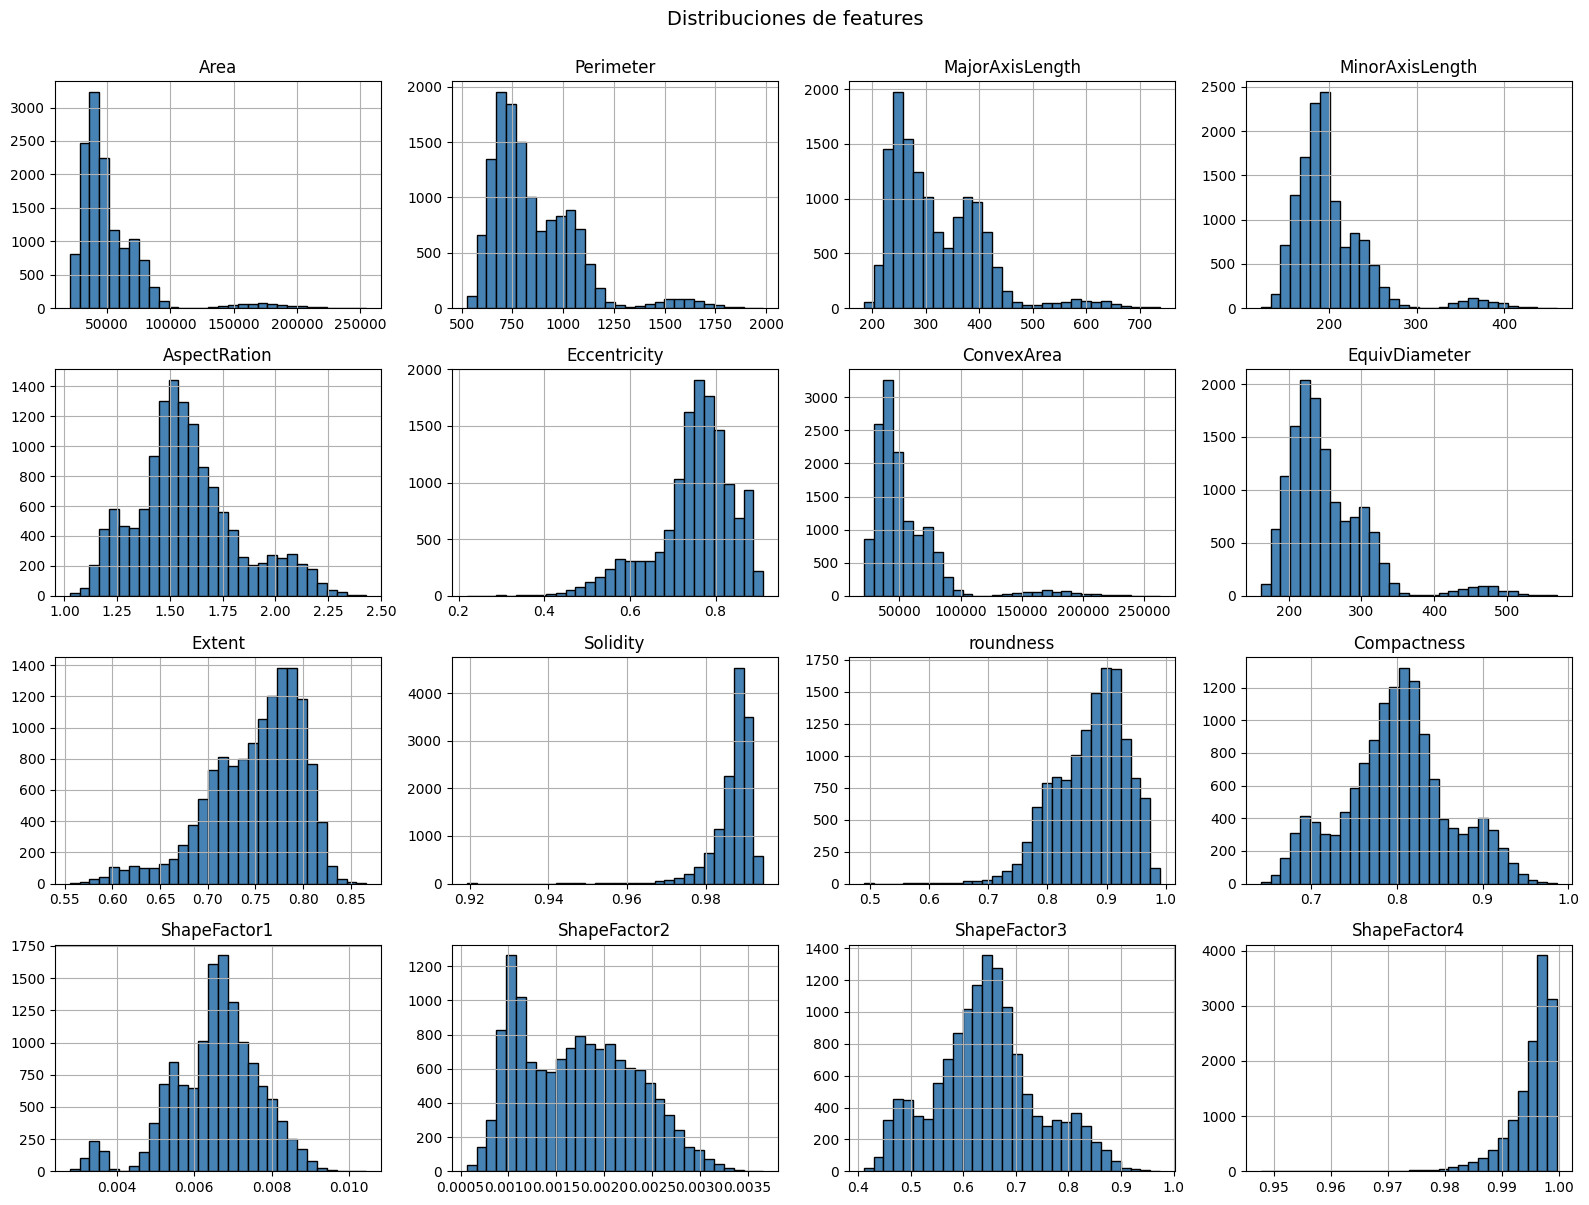

In [16]:
import numpy as np
features = df.select_dtypes(include=np.number).columns.tolist()

df[features].hist(bins=30, figsize=(16, 12), color='steelblue', edgecolor='black')
plt.suptitle('Distribuciones de features', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

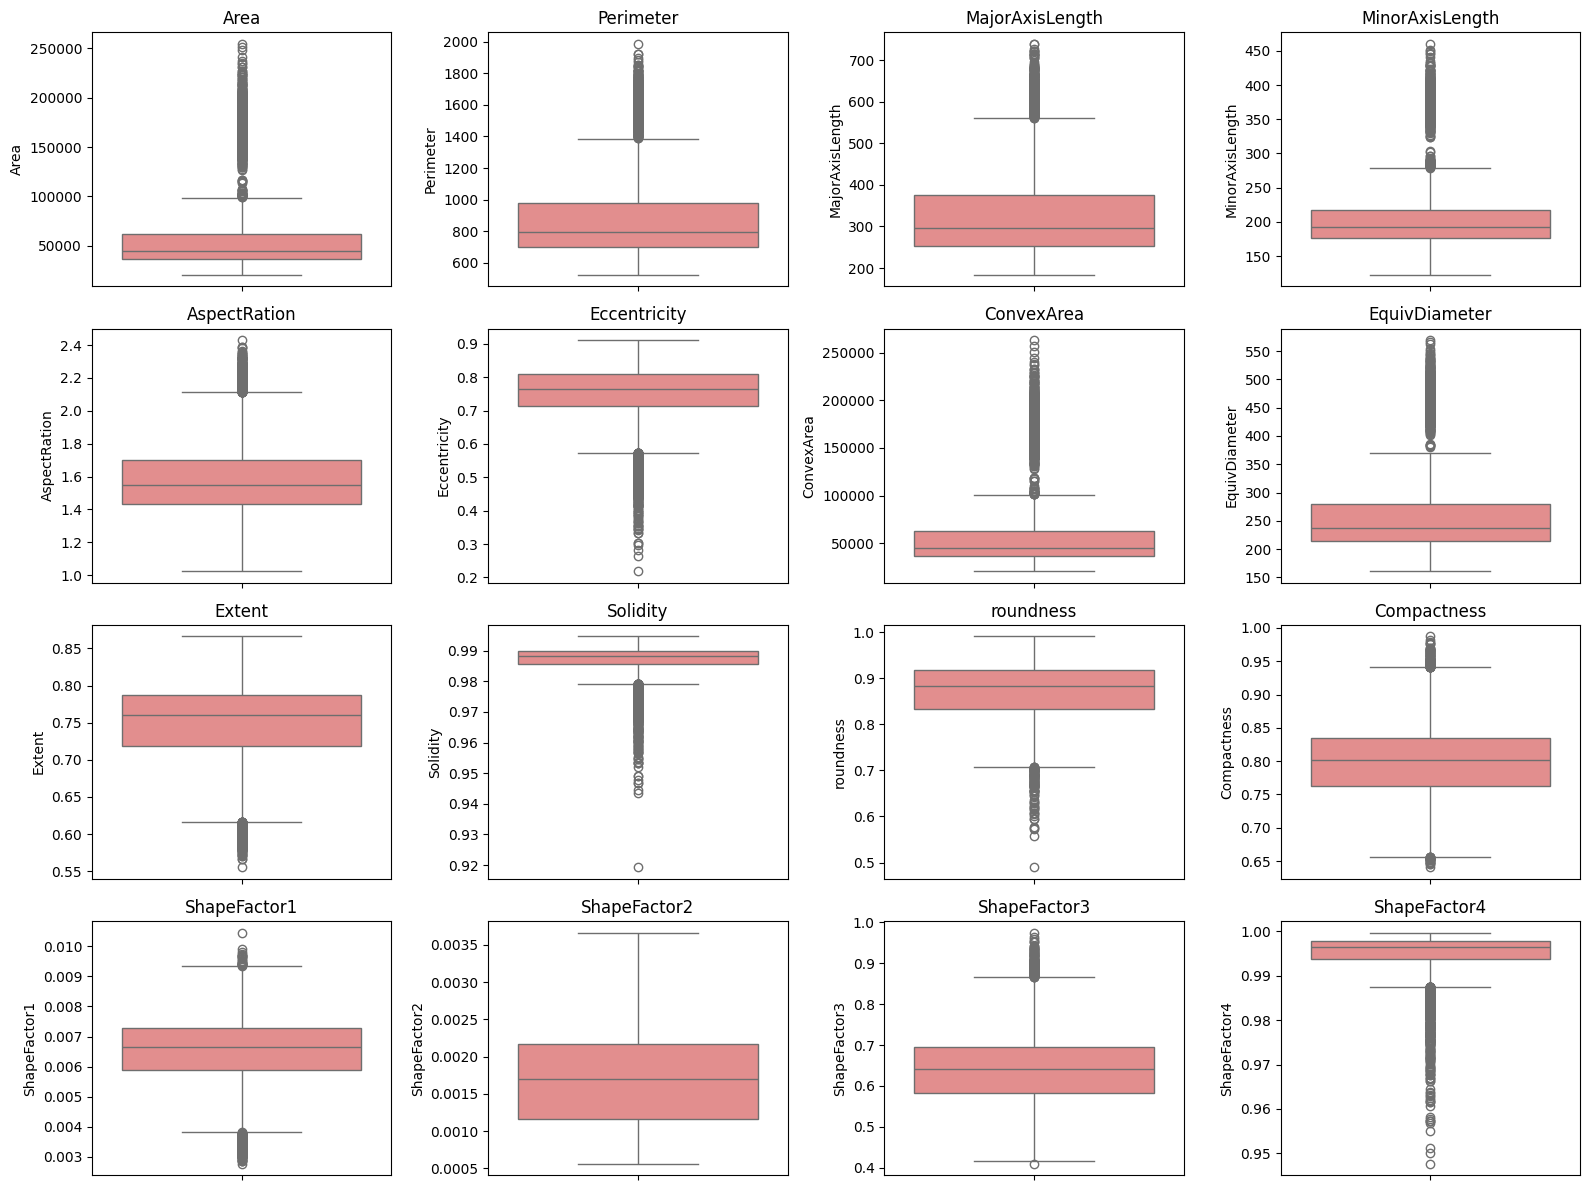

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data=df, y=col, ax=ax, color='lightcoral')
    ax.set_title(col)
plt.tight_layout()
plt.show()

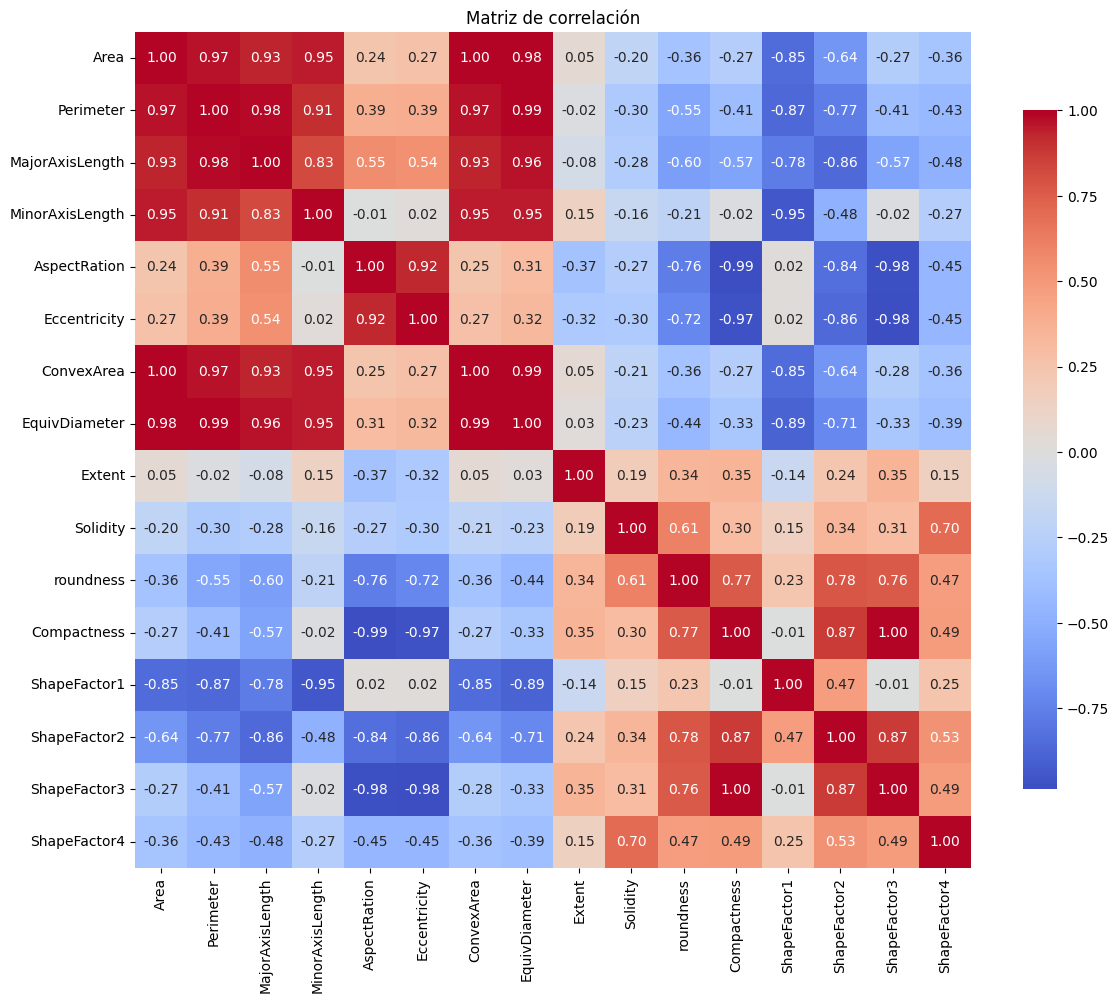

In [18]:
plt.figure(figsize=(12, 10))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2014/1945685853.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_2014/1945685853.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_2014/1945685853.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_2014/1945685853.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign

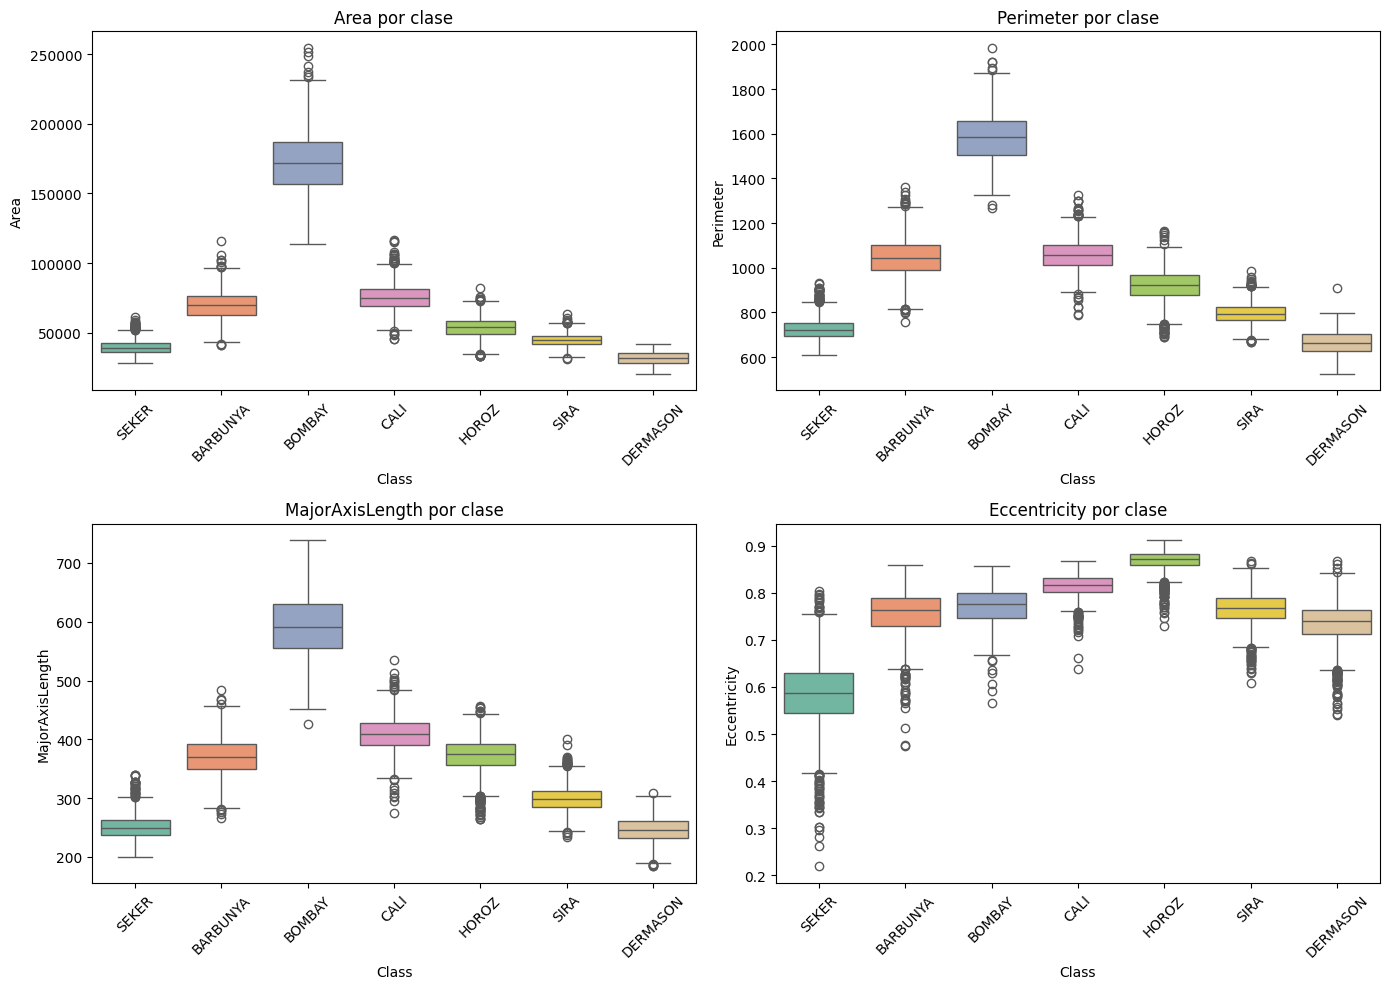

In [19]:
key_features = ['Area', 'Perimeter', 'MajorAxisLength', 'Eccentricity']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x='Class', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} por clase')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

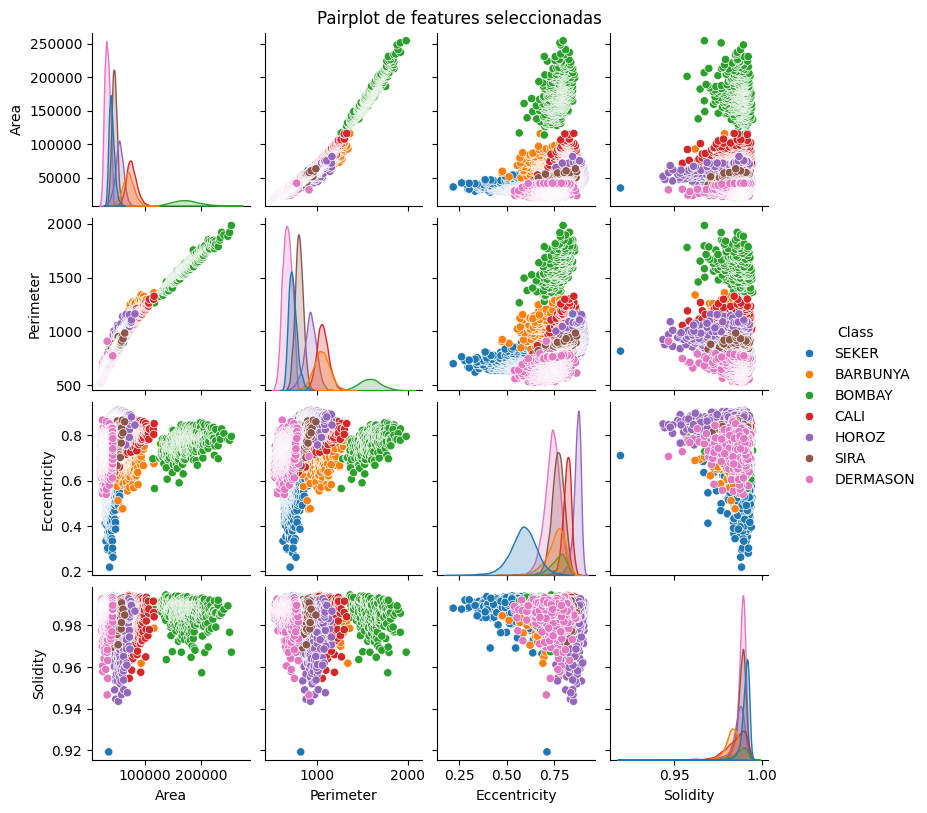

In [20]:
sns.pairplot(df[['Area', 'Perimeter', 'Eccentricity', 'Solidity', 'Class']],
             hue='Class', palette='tab10', diag_kind='kde', height=2)
plt.suptitle('Pairplot de features seleccionadas', y=1.01)
plt.show()

# Training

## Entrenamiento - Modelo Baseline

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

baseline_model = Pipeline(steps=[
("scaler", StandardScaler()),
("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average="macro")
print("Accuracy baseline:", accuracy_baseline)
print("F1 macro baseline:", f1_baseline)
print(classification_report(y_test, y_pred_baseline))

Accuracy baseline: 0.9191583610188261
F1 macro baseline: 0.9302365421734592
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



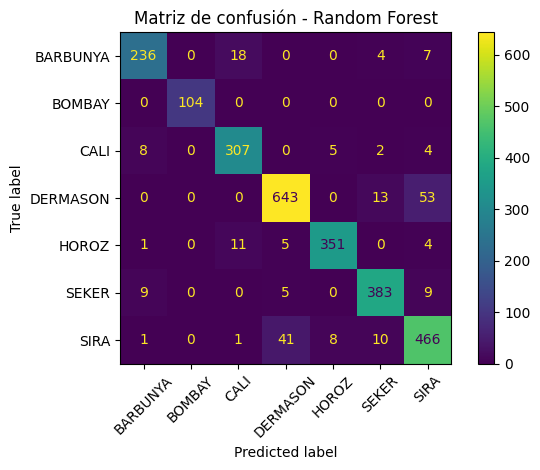

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
y_test,
y_pred_baseline,
xticks_rotation=45
)
plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show()

## Entrenamiento - Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
n_estimators=200,
random_state=42,
class_weight="balanced"
)
forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)
accuracy_forest = accuracy_score(y_test, y_pred_forest)
f1_forest = f1_score(y_test, y_pred_forest, average="macro")
print("Accuracy Random Forest:", accuracy_forest)
print("F1 macro Random Forest:", f1_forest)
print(classification_report(y_test, y_pred_forest))

Accuracy Random Forest: 0.9191583610188261
F1 macro Random Forest: 0.9303396642494651
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.95      0.95       372
       SEKER       0.95      0.95      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



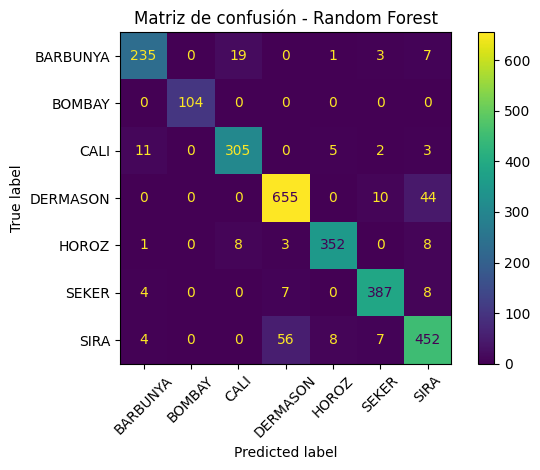

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
y_test,
y_pred_forest,
xticks_rotation=45
)
plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show()

# Comparación Resultados

In [28]:
results = pd.DataFrame({
"modelo": ["Logistic Regression", "Random Forest"],
"accuracy": [accuracy_baseline, accuracy_forest],
"f1_macro": [f1_baseline, f1_forest]
})
print(results)

                modelo  accuracy  f1_macro
0  Logistic Regression  0.919158  0.930237
1        Random Forest  0.919158  0.930340


/tmp/ipykernel_2014/1252315940.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_lr, x="importance", y="feature", palette="Blues_d")


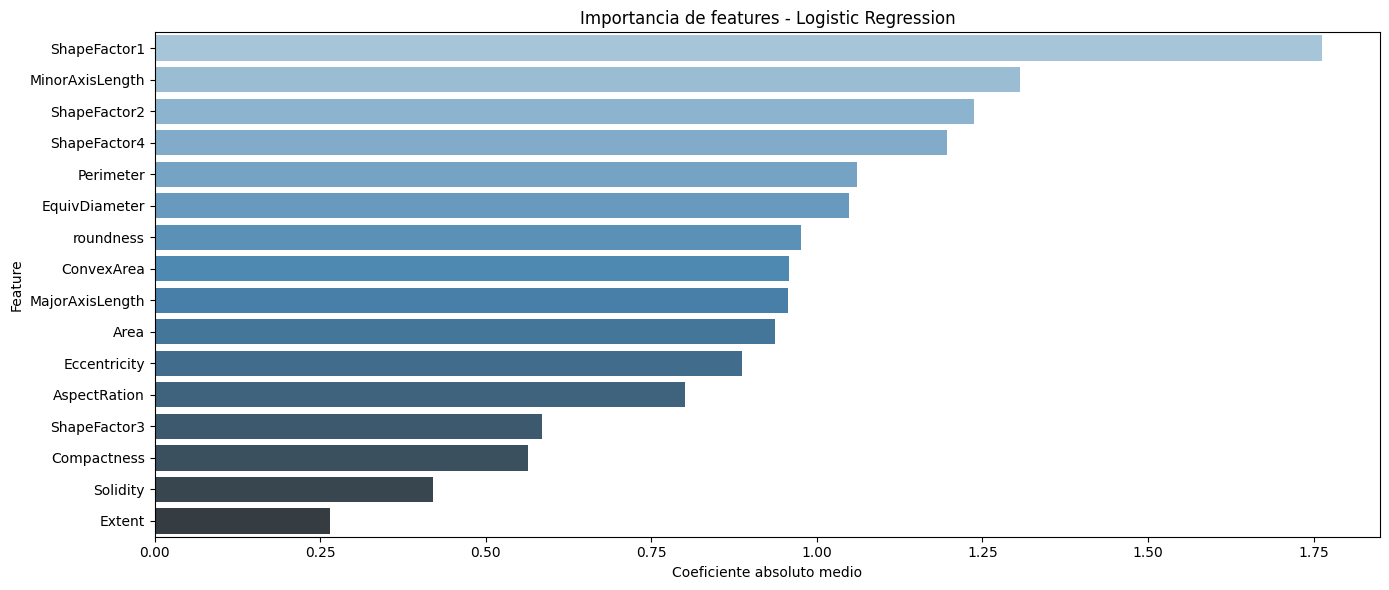

/tmp/ipykernel_2014/1252315940.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_rf, x="importance", y="feature", palette="Greens_d")


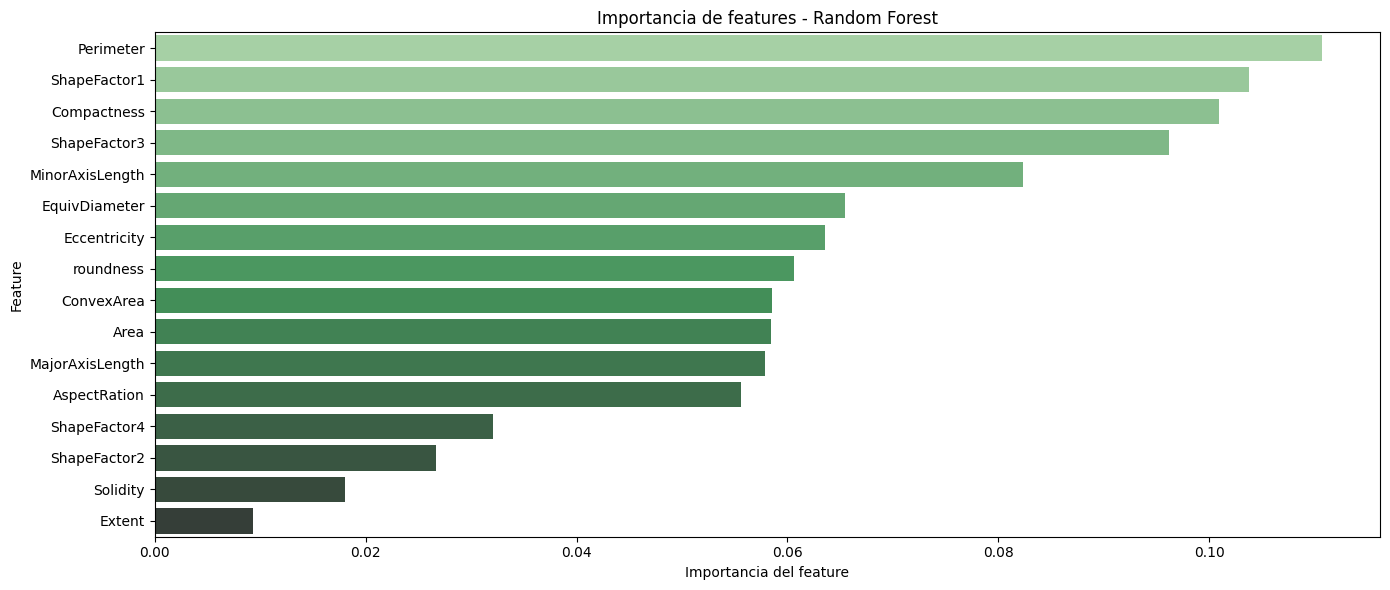

Top 10 Logistic Regression
            feature  importance
12     ShapeFactor1    1.762288
3   MinorAxisLength    1.306634
13     ShapeFactor2    1.236721
15     ShapeFactor4    1.195814
1         Perimeter    1.061154
7     EquivDiameter    1.048377
10        roundness    0.976700
6        ConvexArea    0.957632
2   MajorAxisLength    0.956463
0              Area    0.936185

Top 10 Random Forest
            feature  importance
1         Perimeter    0.110657
12     ShapeFactor1    0.103784
11      Compactness    0.100960
14     ShapeFactor3    0.096224
3   MinorAxisLength    0.082303
7     EquivDiameter    0.065410
5      Eccentricity    0.063603
10        roundness    0.060583
6        ConvexArea    0.058514
0              Area    0.058437


In [35]:
lr_coefs = np.mean(np.abs(baseline_model.named_steps["classifier"].coef_), axis=0)

importance_lr = pd.DataFrame({
    "feature": X.columns,
    "importance": lr_coefs
}).sort_values("importance", ascending=False)

importance_rf = pd.DataFrame({
    "feature": X.columns,
    "importance": forest_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=importance_lr, x="importance", y="feature", palette="Blues_d")
plt.title("Importancia de features - Logistic Regression")
plt.xlabel("Coeficiente absoluto medio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=importance_rf, x="importance", y="feature", palette="Greens_d")
plt.title("Importancia de features - Random Forest")
plt.xlabel("Importancia del feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 10 Logistic Regression")
print(importance_lr.head(10))

print("\nTop 10 Random Forest")
print(importance_rf.head(10))
